In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#### Data Preprocessing

In [130]:
isolation = pd.read_csv("../data/isolation.csv")
isolation.head()

,x,y,color
0,79.408289,152.834424,0
1,98.046263,186.910700,0
2,240.578979,48.473684,1
3,109.687183,277.945769,0
4,249.626082,229.753352,1


In [131]:
isolation["x"] = np.round(isolation['x'])
isolation["y"] = np.round(isolation['y'])
isolation.head()

,x,y,color
0,79.0,153.0,0
1,98.0,187.0,0
2,241.0,48.0,1
3,110.0,278.0,0
4,250.0,230.0,1


In [132]:
scaler = StandardScaler()

In [133]:
isolation["x"] = scaler.fit_transform(np.array(isolation["x"]).reshape(-1,1))
isolation["y"] = scaler.fit_transform(np.array(isolation["y"]).reshape(-1,1))
isolation.head()

,x,y,color
0,-1.204370,-0.716928,0
1,-1.069086,-0.372659,0
2,-0.050900,-1.780112,1
3,-0.983644,0.548768,0
4,0.013181,0.062740,1


#### Data Visualiztion

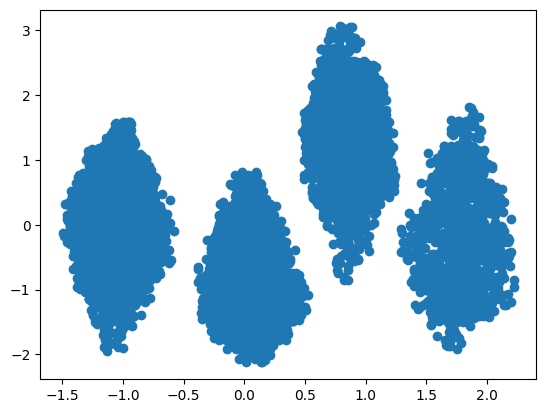

In [134]:
plt.scatter(isolation["x"],isolation["y"])

#### Machine Learing (K-Means Clustering)

In [135]:
Km = KMeans(n_clusters=4)

In [136]:
Km.fit(isolation[['x']],isolation[['y']])

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4)

In [137]:
y_predict = Km.predict(isolation[["x"]])
y_predict

array([2, 2, 0, ..., 1, 1, 3])

In [138]:
# Detected Clustors
np.unique(y_predict)

array([0, 1, 2, 3])

In [139]:
isolation['predicted'] = y_predict

In [140]:
# Let us see centeriods
Km.cluster_centers_

array([[ 0.03791181],
       [ 1.77756276],
       [-1.05592237],
       [ 0.84672156]])

In [141]:
isolation.head()

,x,y,color,predicted
0,-1.204370,-0.716928,0,2
1,-1.069086,-0.372659,0,2
2,-0.050900,-1.780112,1,0
3,-0.983644,0.548768,0,2
4,0.013181,0.062740,1,0


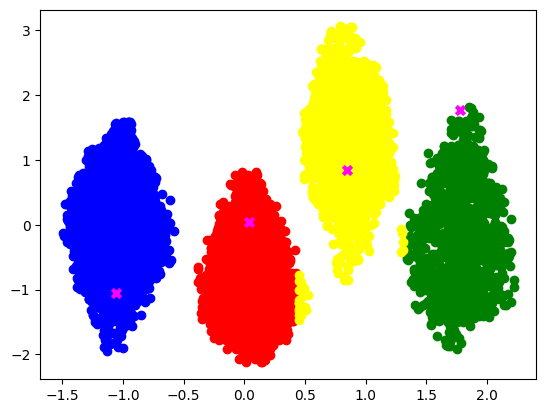

In [142]:
df1 = isolation[isolation["predicted"]== 0]
df2 = isolation[isolation["predicted"]== 1]
df3 = isolation[isolation["predicted"]== 2]
df4 = isolation[isolation["predicted"]== 3]

plt.scatter(df1["x"],df1["y"],c='r')
plt.scatter(df2["x"],df2["y"],c='g')
plt.scatter(df3["x"],df3["y"],c='b')
plt.scatter(df4["x"],df4["y"],c='yellow')
plt.scatter(Km.cluster_centers_[:,0],Km.cluster_centers_[:,0],c="fuchsia",marker="x",linewidths=3)

In [158]:
# Find the elbow point
k_range = range(1,5)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(isolation[["x"]],isolation[["y"]])
    sse.append(Km.inertia_)

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\si

In [159]:
sse

[270.3683680811509, 270.3683680811509, 270.3683680811509, 270.3683680811509]